In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)
df = state_labels.smooth_regime(df)

[*********************100%***********************]  1 of 1 completed


In [72]:
df.head()

,Price,Log Return,Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,,
2008-01-03,103.445641,-0.000483,NaN,NaN,NaN,0,NaN
2008-01-04,100.910561,-0.024812,-0.024506,NaN,NaN,0,NaN
2008-01-07,100.824852,-0.000850,-0.000849,NaN,NaN,0,NaN
2008-01-08,99.196655,-0.016281,-0.016149,NaN,NaN,0,NaN
2008-01-09,100.239281,0.010456,0.010511,NaN,NaN,0,0.0


In [73]:
df.tail()

,Price,Log Return,Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,,
2017-12-22,235.453140,-0.000262,-0.000262,2.310020,0.003561,0,1.0
2017-12-26,235.171555,-0.001197,-0.001196,2.250616,0.003566,0,1.0
2017-12-27,235.285965,0.000486,0.000486,2.221705,0.003566,0,1.0
2017-12-28,235.770035,0.002055,0.002057,2.298738,0.003542,0,1.0
2017-12-29,234.881042,-0.003778,-0.003771,2.209393,0.003541,0,1.0


In [74]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2017-12-15,0.008293,2.033891,0.003381,0,1.0
2017-12-18,0.006321,2.143429,0.003474,0,1.0
2017-12-19,-0.003848,2.290368,0.003533,0,1.0
2017-12-20,-0.000524,2.274190,0.003570,0,1.0
2017-12-21,0.002057,2.297564,0.003576,0,1.0
2017-12-22,-0.000262,2.310020,0.003561,0,1.0
2017-12-26,-0.001197,2.250616,0.003566,0,1.0
2017-12-27,0.000486,2.221705,0.003566,0,1.0
2017-12-28,0.002055,2.298738,0.003542,0,1.0


In [75]:
df[['Vol State', 'Regime']].dropna().dtypes

Vol State      int64
Regime       float64
dtype: object

In [76]:
df['Log Return'].std()

0.012807906103132321

In [77]:
df['T-Stat_200'].describe()

count    2317.000000
mean        0.843340
std         0.904354
min        -1.691394
25%         0.220202
50%         0.904597
75%         1.585436
max         2.575026
Name: T-Stat_200, dtype: float64

In [78]:
df['Volatility'].describe()

count    2457.000000
mean        0.010660
std         0.007262
min         0.003136
25%         0.006815
50%         0.008264
75%         0.012081
max         0.047614
Name: Volatility, dtype: float64

In [79]:
df.isna().sum()

Price           0
Log Return      0
Return          1
T-Stat_200    200
Volatility     60
Vol State       0
Regime          4
dtype: int64

In [80]:
df['Regime'].value_counts(normalize = True)

Regime
 1.0    0.757262
-1.0    0.163152
 0.0    0.079586
Name: proportion, dtype: float64

In [81]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.810886
1    0.189114
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

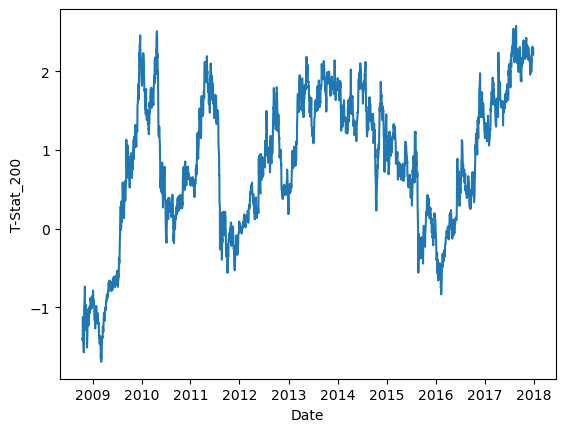

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

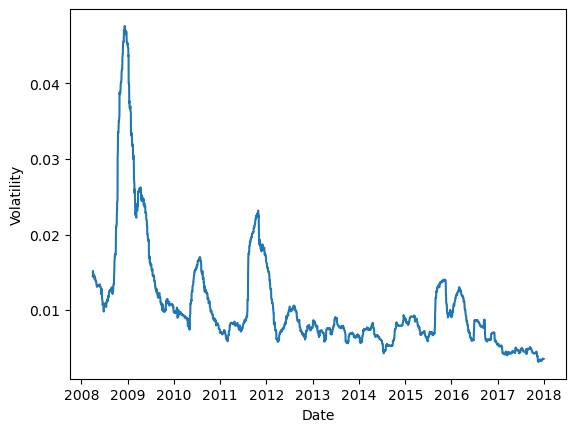

In [83]:
sns.lineplot(data = df['Volatility'])

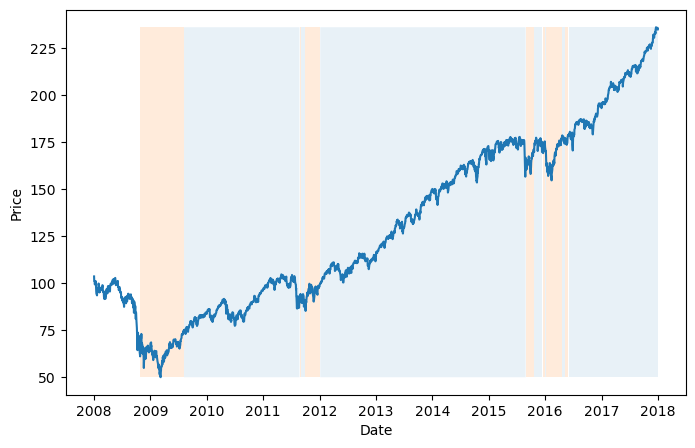

In [84]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['Price'], ax = ax)
ax.fill_between(df.index, df['Price'].min(), df['Price'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['Price'].min(), df['Price'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [85]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.00046020685232086916
-0.0020508456684479146
0.0009423774379374012


count    410.000000
mean       0.000942
std        0.020286
min       -0.092749
25%       -0.009382
50%        0.000948
75%        0.010601
max        0.110518
Name: Forward Return, dtype: float64

In [86]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1.0    0.020286
 0.0    0.021985
 1.0    0.008760
Name: Forward Return, dtype: float64

In [87]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

0.9406258263819417


In [88]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.291023759404703


In [89]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

-1.3192053159670287


In [90]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.010171
1    0.012696
Name: Forward Vol, dtype: float64

In [91]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State    -1.0_0    -1.0_1  0.0_0     1.0_0     1.0_1  nan_0
State                                                           
-1.0_0      0.976190  0.003968  0.000  0.019841  0.000000   0.00
-1.0_1      0.025316  0.962025  0.000  0.000000  0.012658   0.00
0.0_0       0.005000  0.000000  0.995  0.000000  0.000000   0.00
1.0_0       0.000631  0.000631  0.000  0.989899  0.008838   0.00
1.0_1       0.000000  0.012579  0.000  0.037736  0.949686   0.00
nan_0       0.000000  0.000000  0.250  0.000000  0.000000   0.75


In [92]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
-1.0_0    0.123244
-1.0_1    0.185625
0.0_0     0.031479
1.0_0     0.061146
1.0_1     0.227734
nan_0     0.562335
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

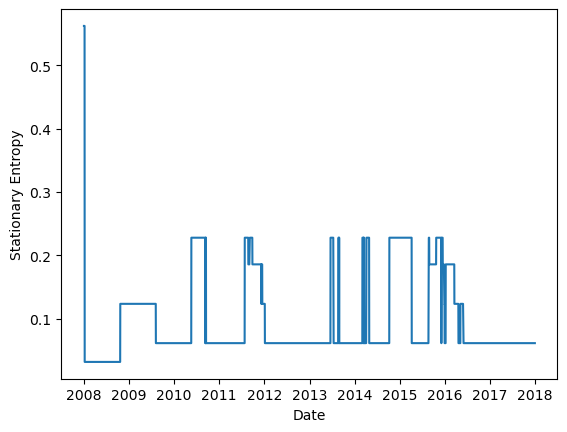

In [93]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

<Axes: xlabel='Date', ylabel='Expanding Entropy'>

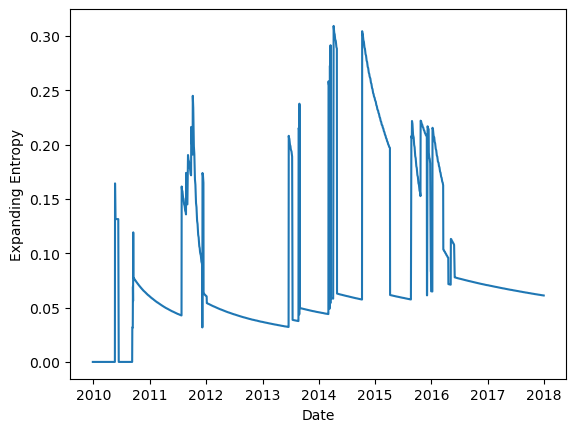

In [94]:
df = entropy.build_expanding_entropy(df)

sns.lineplot(data = df['Expanding Entropy'])

In [95]:
df['Expanding Entropy'].describe()

count    2017.000000
mean        0.081853
std         0.067578
min        -0.000000
25%         0.045010
50%         0.060909
75%         0.075536
max         0.309263
Name: Expanding Entropy, dtype: float64

In [96]:
df[[f'T-Stat_200', 'Log Return']].corr()

,T-Stat_200,Log Return
T-Stat_200,1.00000,-0.02669
Log Return,-0.02669,1.00000


In [97]:
df[['Volatility', 'Log Return']].corr()

,Volatility,Log Return
Volatility,1.000000,-0.017795
Log Return,-0.017795,1.000000


In [98]:
df[[f'T-Stat_200', 'Forward Return']].corr()

,T-Stat_200,Forward Return
T-Stat_200,1.000000,-0.023142
Forward Return,-0.023142,1.000000


In [99]:
df[['Volatility', 'Forward Return']].corr()

,Volatility,Forward Return
Volatility,1.000000,-0.019586
Forward Return,-0.019586,1.000000


In [100]:
from backtests import exposure

df = exposure.normalize_entropy(df)
df = exposure.normalize_tstat(df)
df = exposure.create_exposure(df)

In [101]:
df['Exposure'].describe()

count    2497.000000
mean        0.167163
std         0.379130
min        -0.837512
25%        -0.120820
50%         0.195807
75%         0.456059
max         0.938903
Name: Exposure, dtype: float64

In [102]:
(df['Exposure'].abs() > 0.8).mean()

0.030194676201827572

In [103]:
df['Trend'].describe()

count    2497.000000
mean        0.172856
std         0.393802
min        -0.837512
25%        -0.128517
50%         0.202311
75%         0.467675
max         0.938903
Name: Trend, dtype: float64

In [104]:
df['Confidence'].describe()

count    2517.000000
mean        0.963392
std         0.038369
min         0.827397
25%         0.960388
50%         0.970882
75%         1.000000
max         1.000000
Name: Confidence, dtype: float64

In [105]:
df['Exposure'].autocorr(lag = 1)

0.936639127518749

In [106]:
df[['Exposure', 'Log Return']].corr()

,Exposure,Log Return
Exposure,1.000000,-0.020247
Log Return,-0.020247,1.000000


In [107]:
df[['Exposure', 'Forward Return']].corr()

,Exposure,Forward Return
Exposure,1.000000,-0.010717
Forward Return,-0.010717,1.000000


In [108]:
df.groupby('Vol State')['Exposure'].mean()

Vol State
0    0.203387
1    0.013362
Name: Exposure, dtype: float64

In [109]:
df.groupby('Regime')['Exposure'].mean()

Regime
-1.0    0.039513
 0.0   -0.119184
 1.0    0.222351
Name: Exposure, dtype: float64

In [110]:
df['Exposure Change'] = df['Exposure'].diff().abs()
df['Exposure Change'].mean()

0.10170890007072636

Text(0, 0.5, 'Exposure')

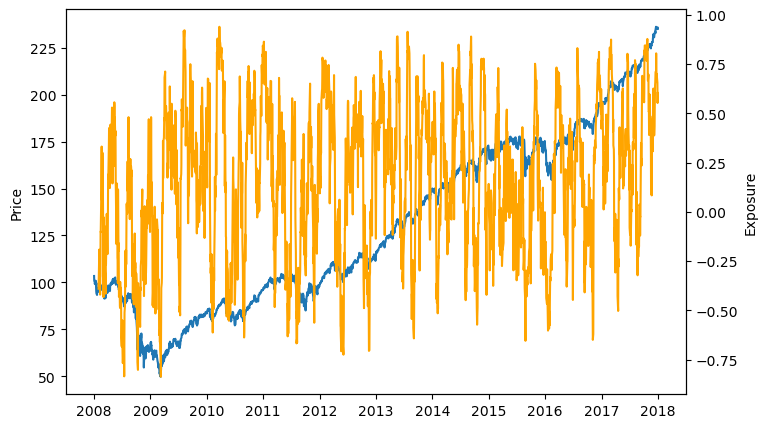

In [111]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Price'], label = 'Price')
ax1.set_ylabel('Price')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

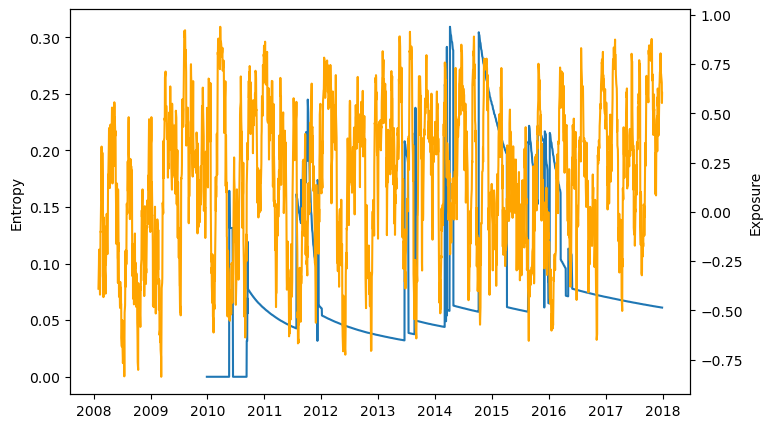

In [112]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Expanding Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

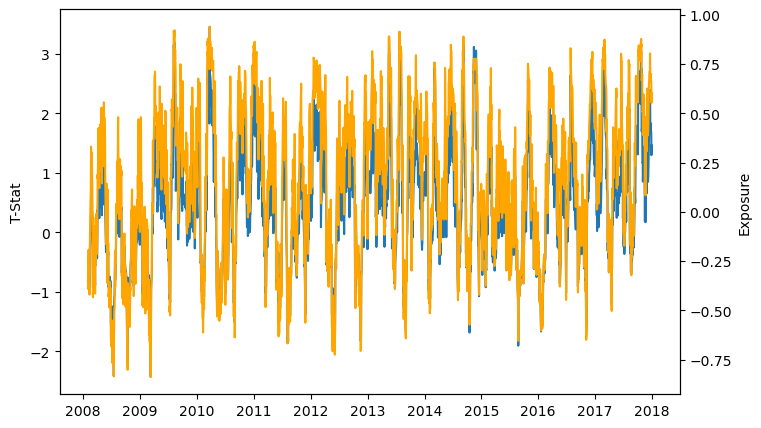

In [113]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['T-Stat_20'], label = 'T-Stat-20')
ax1.set_ylabel('T-Stat')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

<Axes: xlabel='Date'>

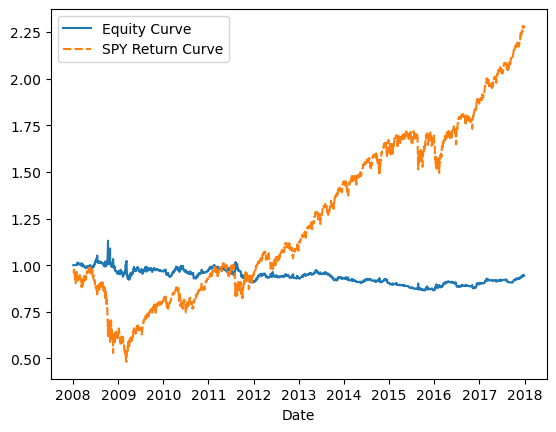

In [114]:
from backtests import backtest

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

<Axes: xlabel='Date', ylabel='Exposure'>

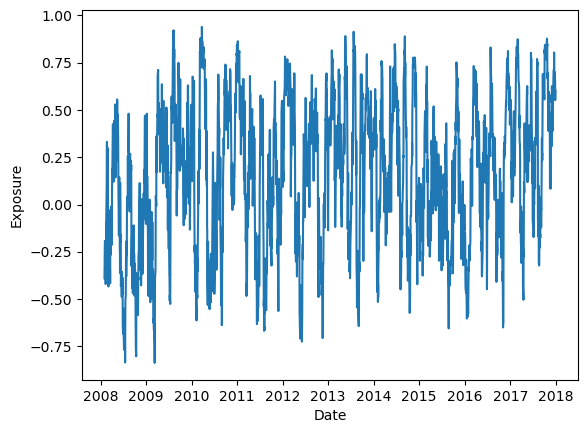

In [115]:
sns.lineplot(data = df['Exposure'])

In [116]:
(df['Exposure'] < 0).mean()

0.3357171235597934

In [117]:
df['Exposure'].corr(df['Pct Return'].shift(-1))

-0.016386930419136747

In [118]:
df['Expanding Entropy'].corr(df['Forward Vol'])

0.2671817331605718

<Axes: xlabel='Date'>

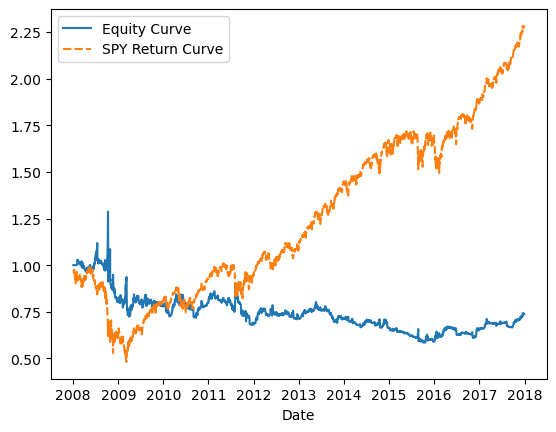

In [119]:
df['Exposure'] = df['T-Stat_20']
df['Exposure'].clip(0, 1)

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [120]:
(df['Exposure'] < 0).mean()

0.3357171235597934

<Axes: xlabel='Date'>

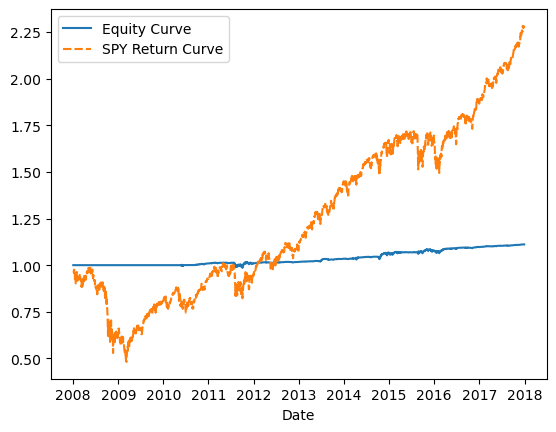

In [121]:
df['Exposure'] = df['Expanding Entropy']

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [122]:
import pandas as pd

df['Entropy Bins'] = pd.cut(df['Expanding Entropy'], bins = [0, 0.15, 0.4, 1], labels = ['Low', 'Mid', 'High'])

df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()

/var/folders/qd/xclxh05s0x9509nblm6z434w0000gp/T/ipykernel_88629/93630667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()


,Entropy Bins,Forward Vol
0,Low,0.007586
1,Mid,0.011399
2,High,NaN


<Axes: xlabel='Date'>

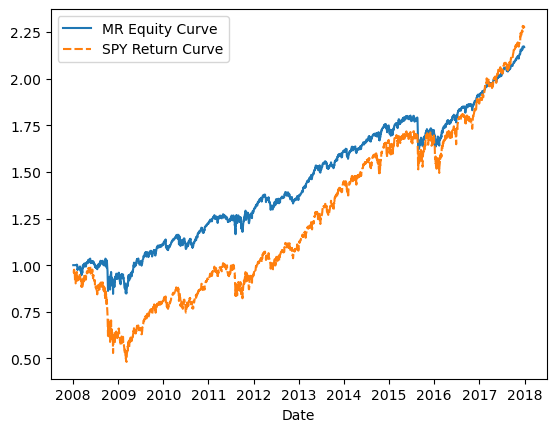

In [123]:
from backtests import mean_reversion
from features import zscore

df = zscore.calculate_zscore(df)
df = mean_reversion.generate_signal(df)
df = mean_reversion.mr_backtest(df)
sns.lineplot(data = df[['MR Equity Curve', 'SPY Return Curve']])

In [124]:
print(df['MR Signal'].describe())

count    2497.000000
mean        0.505244
std         0.202444
min         0.034191
25%         0.357382
50%         0.507389
75%         0.644161
max         0.977452
Name: MR Signal, dtype: float64


In [125]:
from evaluation import metrics

print(f"Mean-reversion-only Sharpe: {metrics.calculate_sharpe(df['MR Return'])}")
print(f"Mean-reversion-only max drawdown: {metrics.calculate_max_drawdown(df['MR Return'])}")

Mean-reversion-only Sharpe: 0.7438613448515247
Mean-reversion-only max drawdown: -0.18263249195895295


252


<Axes: xlabel='Date'>

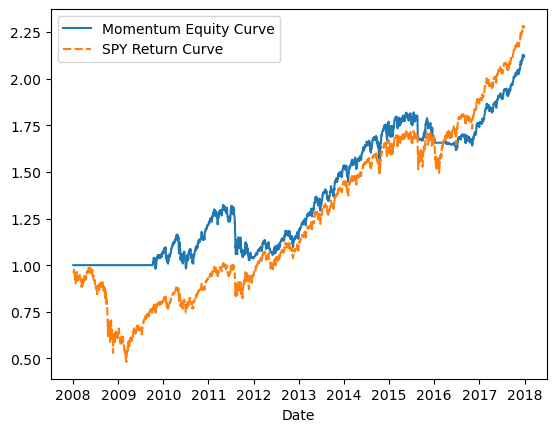

In [126]:
from backtests import momentum_backtest
from features import momentum

df = momentum.calculate_momentum(df)
df = momentum_backtest.generate_signal(df)
df = momentum_backtest.momentum_backtest(df)
sns.lineplot(data = df[['Momentum Equity Curve', 'SPY Return Curve']])

In [127]:
print(f"Momentum-only Sharpe: {metrics.calculate_sharpe(df['Momentum Return'])}")
print(f"Momentum-only max drawdown: {metrics.calculate_max_drawdown(df['Momentum Return'])}")

Momentum-only Sharpe: 0.6987962002996535
Momentum-only max drawdown: -0.22397617513142615


In [128]:
df['Momentum Signal'].describe()

count    2265.000000
mean        0.818675
std         0.359271
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Momentum Signal, dtype: float64

In [129]:
df['Momentum'].describe()

count    2265.000000
mean        0.099576
std         0.168280
min        -0.641582
25%         0.052112
50%         0.138260
75%         0.189540
max         0.541987
Name: Momentum, dtype: float64

In [130]:
print(f"SPY Sharpe: {metrics.calculate_sharpe(df['Pct Return'])}")
print(f"SPY max drawdown: {metrics.calculate_max_drawdown(df['Pct Return'])}")

SPY Sharpe: 0.5053317473031742
SPY max drawdown: -0.5148146521410742


<Axes: xlabel='Date'>

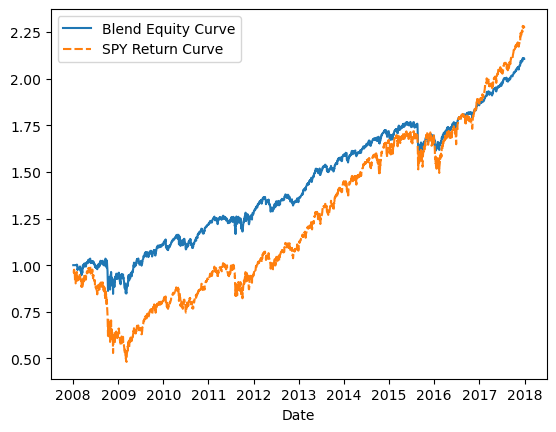

In [131]:
from backtests import blend_signal

df = blend_signal.generate_signal(df)
df = blend_signal.blended_backtest(df)
sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [132]:
print(f"Blend Sharpe: {metrics.calculate_sharpe(df['Blend Return'])}")
print(f"Blend max drawdown: {metrics.calculate_max_drawdown(df['Blend Return'])}")

Blend Sharpe: 0.7325833812944204
Blend max drawdown: -0.18263249195895295


In [133]:
print(df['Confidence'].describe())
print(df['State'].value_counts())

count    2517.000000
mean        0.963392
std         0.038369
min         0.827397
25%         0.960388
50%         0.970882
75%         1.000000
max         1.000000
Name: Confidence, dtype: float64
State
1.0_0     1585
1.0_1      318
-1.0_0     252
0.0_0      200
-1.0_1     158
nan_0        4
Name: count, dtype: int64


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

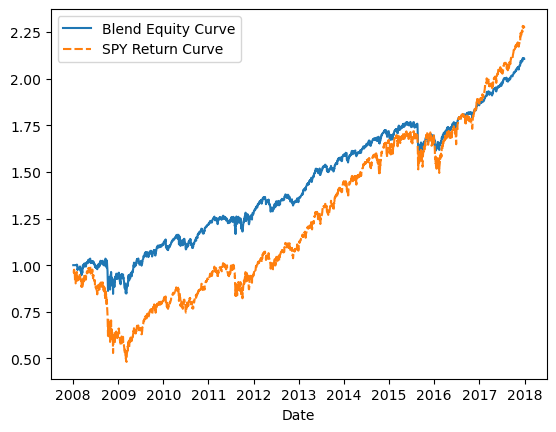

In [134]:
from pipeline import run

test = run.run_pipeline('SPY')

sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [135]:
print(f'Blend annualized returns: {metrics.calculate_annualized_returns(df['Blend Return'])}')
print(f'Blend Sortino ratio: {metrics.calculate_sortino(df['Blend Return'])}')
print(f'Blend Calmar ratio: {metrics.calculate_calmar(df['Blend Return'])}')

Blend annualized returns: 0.07730970800906967
Blend Sortino ratio: 0.8861432740950484
Blend Calmar ratio: 0.42330752419698237


In [136]:
print(f'SPY annualized returns: {metrics.calculate_annualized_returns(df['Pct Return'])}')
print(f'SPY Sortino ratio: {metrics.calculate_sortino(df['Pct Return'])}')
print(f'SPY Calmar ratio: {metrics.calculate_calmar(df['Pct Return'])}')

SPY annualized returns: 0.0854472000233164
SPY Sortino ratio: 0.6154375360937615
SPY Calmar ratio: 0.16597662803097799


In [137]:
df

,Price,Log Return,Return,T-Stat_200,Volatility,Vol State,Regime,Forward Return,Forward Vol,State,...,MR Signal,MR Return,MR Equity Curve,Momentum,Momentum Signal,Momentum Return,Momentum Equity Curve,Blend Signal,Blend Return,Blend Equity Curve
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-03,103.445641,-0.000483,NaN,NaN,NaN,0,NaN,-0.024812,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-04,100.910561,-0.024812,-0.024506,NaN,NaN,0,NaN,-0.000850,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-07,100.824852,-0.000850,-0.000849,NaN,NaN,0,NaN,-0.016281,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-08,99.196655,-0.016281,-0.016149,NaN,NaN,0,NaN,0.010456,NaN,nan_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
2008-01-09,100.239281,0.010456,0.010511,NaN,NaN,0,0.0,0.006533,NaN,0.0_0,...,NaN,0.000000,1.000000,NaN,NaN,0.000000,1.000000,NaN,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-22,235.453140,-0.000262,-0.000262,2.310020,0.003561,0,1.0,-0.001197,0.003566,1.0_0,...,0.481092,-0.000126,2.170293,0.189156,1.0,-0.000262,2.121922,0.464639,-0.000122,2.107947
2017-12-26,235.171555,-0.001197,-0.001196,2.250616,0.003566,0,1.0,0.000486,0.003566,1.0_0,...,0.608503,-0.000728,2.168714,0.190624,1.0,-0.001196,2.119385,0.587704,-0.000703,2.106466
2017-12-27,235.285965,0.000486,0.000486,2.221705,0.003566,0,1.0,0.002055,0.003542,1.0_0,...,0.657001,0.000320,2.169407,0.187964,1.0,0.000486,2.120416,0.634556,0.000309,2.107116


<Axes: xlabel='Date', ylabel='Rolling Entropy'>

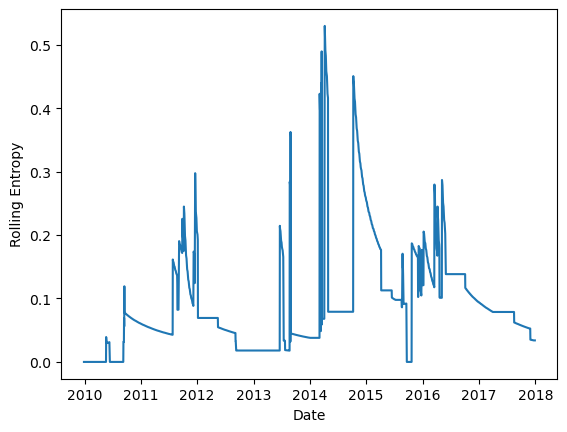

In [138]:
df = entropy.build_rolling_entropy(df)

sns.lineplot(data = df['Rolling Entropy'])